In [21]:
import os
os.environ["KAGGLEHUB_CACHE"] = r"G:\ML\kagglehub"

import kagglehub
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

import numpy as np, torch, torch.nn as nn, cv2, torchvision
from torch.utils.data import Dataset, DataLoader

In [22]:
path = kagglehub.dataset_download("akashshingha850/mrl-eye-dataset")
print("Path to dataset files:", path)

data_dir = Path(path)

for p in sorted(data_dir.rglob("*")):
    if p.is_dir():
        print(p.relative_to(data_dir))

Path to dataset files: G:\ML\kagglehub\datasets\akashshingha850\mrl-eye-dataset\versions\4
data
data\test
data\test\awake
data\test\sleepy
data\train
data\train\awake
data\train\sleepy
data\val
data\val\awake
data\val\sleepy


In [23]:
for split in ["train", "val", "test"]:
    for cls in ["awake", "sleepy"]:
        folder = data_dir / "data" / split / cls
        n = len(list(folder.glob("*.png")))
        print(f"{split:6s} {cls:8s} {n:6d}")

train  awake     25770
train  sleepy    25167
val    awake      8591
val    sleepy     8389
test   awake      8591
test   sleepy     8390


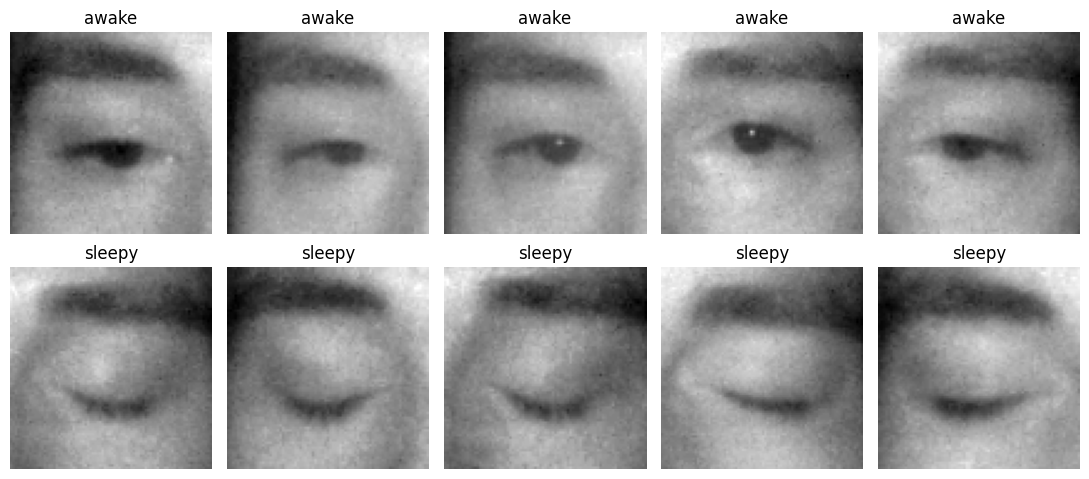

In [24]:
awake_files  = sorted((data_dir / "data" / "train" / "awake").glob("*.png"))[:5]
sleepy_files = sorted((data_dir / "data" / "train" / "sleepy").glob("*.png"))[:5]

fig, axes = plt.subplots(2, 5, figsize=(11, 5))

for ax, f in zip(axes[0], awake_files):
    ax.imshow(plt.imread(f), cmap="gray")
    ax.set_title("awake")
    ax.axis("off")

for ax, f in zip(axes[1], sleepy_files):
    ax.imshow(plt.imread(f), cmap="gray")
    ax.set_title("sleepy")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [25]:
for f in awake_files[:3]:
    print("awake :", f.name)

for f in sleepy_files[:3]:
    print("sleepy:", f.name)

awake : s0001_01842_0_0_1_0_0_01.png
awake : s0001_01843_0_0_1_0_0_01.png
awake : s0001_01845_0_0_1_0_0_01.png
sleepy: s0001_00002_0_0_0_0_0_01.png
sleepy: s0001_00005_0_0_0_0_0_01.png
sleepy: s0001_00006_0_0_0_0_0_01.png


In [26]:
def subject_of(path):
    return path.name.split("_")[0]

subjects = {}

for split in ["train", "val", "test"]:
    people = set()
    for cls in ["awake", "sleepy"]:
        for f in (data_dir / "data" / split / cls).glob("*.png"):
            people.add(subject_of(f))
    subjects[split] = people
    print(f"{split:6s} — distinct people: {len(people)}")

print()
print("People present in BOTH train and test:", len(subjects["train"] & subjects["test"]))

train  — разных людей: 37
val    — разных людей: 37
test   — разных людей: 37

Людей, которые есть И в train, И в test: 37


In [27]:
rows = []

for split in ["train", "val", "test"]:
    for cls in ["awake", "sleepy"]:
        for f in (data_dir / "data" / split / cls).glob("*.png"):
            parts = f.stem.split("_")
            rows.append({
                "path":         str(f.relative_to(data_dir)),
                "subject":      parts[0],
                "glasses":      int(parts[3]),
                "eye_state":    int(parts[4]),   # 0 = closed, 1 = open
                "reflections":  int(parts[5]),
                "lighting":     int(parts[6]),
                "folder_class": cls,             # how the dataset authors labelled it
            })

df = pd.DataFrame(rows)
print("Table size:", df.shape)
df.head()

Размер таблицы: (84898, 7)


,path,subject,glasses,eye_state,reflections,lighting,folder_class
0,data\train\awake\s0001_01842_0_0_1_0_0_01.png,s0001,0,1,0,0,awake
1,data\train\awake\s0001_01843_0_0_1_0_0_01.png,s0001,0,1,0,0,awake
2,data\train\awake\s0001_01845_0_0_1_0_0_01.png,s0001,0,1,0,0,awake
3,data\train\awake\s0001_01848_0_0_1_0_0_01.png,s0001,0,1,0,0,awake
4,data\train\awake\s0001_01852_0_0_1_0_0_01.png,s0001,0,1,0,0,awake


In [28]:
pd.crosstab(df["folder_class"], df["eye_state"])

eye_state,0,1
folder_class,,
awake,0,42952
sleepy,41946,0


In [29]:
df["label"] = 1 - df["eye_state"]   # was: 1 = open. now: 1 = CLOSED
print(df["label"].value_counts())

label
0    42952
1    41946
Name: count, dtype: int64


In [30]:
people = (df.groupby("subject")["label"]
            .agg(frames="count", closed="sum")
            .sort_values("frames", ascending=False))
people["closed_share"] = (people["closed"] / people["frames"]).round(2)

print(people.to_string())

         frames  closed  closed_share
subject                              
s0037     10257    6020          0.59
s0014      8884    3768          0.42
s0012      8728    4498          0.52
s0036      6193    2096          0.34
s0019      6175    2907          0.47
s0032      6162     143          0.02
s0018      4410    3689          0.84
s0013      3605    2975          0.83
s0001      3242    1841          0.57
s0016      1889    1716          0.91
s0031      1738     241          0.14
s0011      1648    1508          0.92
s0017      1648    1319          0.80
s0025      1502     137          0.09
s0029      1393     177          0.13
s0030      1384     331          0.24
s0026      1246     409          0.33
s0015      1132     784          0.69
s0002      1114    1007          0.90
s0004      1069    1069          1.00
s0006      1012    1011          1.00
s0021       987     135          0.14
s0008       832     832          1.00
s0024       752     205          0.27
s0034       

In [31]:
targets = {"train": 0.6, "val": 0.2, "test": 0.2}
quota = {s: share * len(df) for s, share in targets.items()}

have = {s: {"frames": 0, "closed": 0} for s in targets}
where = {}

for subject, row in people.iterrows():
    def penalty(s):
        frames = have[s]["frames"] + row["frames"]
        closed = have[s]["closed"] + row["closed"]
        overflow  = frames / quota[s]              # how far past its quota the subset goes
        imbalance = abs(closed / frames - 0.5)     # how skewed its class balance gets
        return overflow + imbalance

    best = min(targets, key=penalty)
    where[subject] = best
    have[best]["frames"] += row["frames"]
    have[best]["closed"] += row["closed"]

df["split"] = df["subject"].map(where)
print(df.groupby("split")["subject"].nunique())

split
test      8
train    22
val       7
Name: subject, dtype: int64


In [32]:
sets = {s: set(df.loc[df["split"] == s, "subject"]) for s in ["train", "val", "test"]}
print("train ∩ val :", len(sets["train"] & sets["val"]))
print("train ∩ test:", len(sets["train"] & sets["test"]))
print("val   ∩ test:", len(sets["val"]   & sets["test"]))
print()

summary = df.groupby("split").agg(
    images=("path", "count"),
    people=("subject", "nunique"),
    closed=("label", "sum"),
)
summary["closed_share"] = (summary["closed"] / summary["images"]).round(3)
summary["img_share"]    = (summary["images"] / len(df)).round(3)
summary

train ∩ val : 0
train ∩ test: 0
val   ∩ test: 0



,images,people,closed,closed_share,img_share
split,,,,,
test,16734,8,8153,0.487,0.197
train,51430,22,25599,0.498,0.606
val,16734,7,8194,0.490,0.197


In [33]:
out_dir = Path("data")
out_dir.mkdir(exist_ok=True)

df.to_csv(out_dir / "manifest.csv", index=False)
print("Saved:", (out_dir / "manifest.csv").resolve())
print("Rows:", len(df))

Сохранено: G:\ML\eyes_detection\data\manifest.csv
Строк: 84898


In [34]:
df = pd.read_csv("data/manifest.csv")
IMG = 64

class EyeDataset(Dataset):
    def __init__(self, frame, root, train):
        self.rows, self.root, self.train = frame.reset_index(drop=True), Path(root), train
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, i):
        r = self.rows.loc[i]
        img = cv2.imread(str(self.root / r["path"]), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG, IMG))
        if self.train:
            if np.random.rand() < 0.5:
                img = cv2.flip(img, 1)

            # gamma: imitates blown highlights and crushed shadows
            img = 255 * (img / 255.0) ** np.random.uniform(0.5, 2.0)

            # brightness and contrast
            img = img * np.random.uniform(0.7, 1.3) + np.random.uniform(-30, 30)

            # sensor noise: the main cure for low light. In the dark the camera
            # raises its gain and the noise grows along with it
            if np.random.rand() < 0.7:
                img = img + np.random.normal(0, np.random.uniform(0, 14), img.shape)

            img = np.clip(img, 0, 255).astype(np.uint8)

            # slight defocus and motion blur
            if np.random.rand() < 0.3:
                img = cv2.GaussianBlur(img, (3, 3), np.random.uniform(0.3, 1.2))
        x = torch.from_numpy(img).float().div(255).sub(0.5).div(0.5).unsqueeze(0)
        return x, torch.tensor(float(r["label"]))

train_dl = DataLoader(EyeDataset(df[df.split=="train"], data_dir, True),  batch_size=256, shuffle=True)
val_dl   = DataLoader(EyeDataset(df[df.split=="val"],   data_dir, False), batch_size=256)
test_dl  = DataLoader(EyeDataset(df[df.split=="test"],  data_dir, False), batch_size=256)
print(len(train_dl.dataset), len(val_dl.dataset), len(test_dl.dataset))

51430 16734 16734


In [35]:
def make_model():
    m = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
    w = m.conv1.weight.data.sum(1, keepdim=True)
    m.conv1 = nn.Conv2d(1, 64, 7, 2, 3, bias=False)
    m.conv1.weight.data = w
    m.fc = nn.Linear(512, 1)
    return m

device = "cuda" if torch.cuda.is_available() else "cpu"
model = make_model().to(device)
print(device)

cuda


In [ ]:
import mlflow

# Хранилище журнала: одна база SQLite в корне проекта. Сервер не нужен,
# хранение в обычной папке в MLflow 3 объявлено устаревшим.
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("eye-state")

RUN_NAME = "resnet18, аугментация с шумом"   # меняй при каждом опыте

opt    = torch.optim.AdamW(model.parameters(), lr=3e-4)
lossf  = nn.BCEWithLogitsLoss()
scaler = torch.amp.GradScaler("cuda")
EPOCHS = 5

def evaluate(dl):
    model.eval(); probs, ys = [], []
    with torch.no_grad():
        for x, y in dl:
            with torch.amp.autocast("cuda"):
                p = torch.sigmoid(model(x.to(device)).squeeze(1))
            probs += p.float().cpu().tolist(); ys += y.tolist()
    return np.array(probs), np.array(ys)

with mlflow.start_run(run_name=RUN_NAME) as run:
    # Условия опыта. Записываем ДО обучения: если оно упадёт, запись
    # всё равно останется, и будет видно, что именно пробовали.
    mlflow.log_params({
        "arch":         "resnet18",
        "pretrained":   True,
        "img_size":     IMG,
        "batch_size":   256,
        "lr":           3e-4,
        "epochs":       EPOCHS,
        "augmentation": "flip, gamma, brightness, noise, blur",
        "train_images": len(train_dl.dataset),
        "val_images":   len(val_dl.dataset),
        "test_images":  len(test_dl.dataset),
    })

    best = 0
    for ep in range(1, EPOCHS + 1):
        model.train()
        running = 0.0
        for x, y in train_dl:
            x, y = x.to(device), y.to(device)
            with torch.amp.autocast("cuda"):
                loss = lossf(model(x).squeeze(1), y)
            opt.zero_grad(); scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            running += loss.item() * len(y)

        p, y = evaluate(val_dl)
        acc = float(((p > 0.5) == y).mean())

        # step=ep — метрика по эпохам, MLflow нарисует её графиком
        mlflow.log_metrics({"train_loss": running / len(train_dl.dataset),
                            "val_acc": acc}, step=ep)
        print(f"epoch {ep}  val acc {acc:.4f}")

        if acc > best:
            best = acc
            torch.save(model.state_dict(), "best.pt")

    mlflow.log_metric("best_val_acc", best)
    mlflow.log_artifact("best.pt")     # веса кладутся рядом с записью опыта

    # запомним номер запуска: ячейки с проверкой допишут результаты сюда же
    RUN_ID = run.info.run_id

print("best val acc:", round(best, 4))
print("run id:", RUN_ID)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

model.load_state_dict(torch.load("best.pt"))
p, y = evaluate(test_dl)
pred = (p > 0.5).astype(int)

matrix = confusion_matrix(y, pred)
report = classification_report(y, pred, target_names=["open", "closed"], digits=4)
auc    = roc_auc_score(y, p)

print(matrix)
print(report)
print("ROC-AUC:", round(auc, 4))

# Дописываем в ТОТ ЖЕ запуск: экзамен — часть опыта, а не отдельное событие.
# start_run с run_id открывает уже закрытую запись.
with mlflow.start_run(run_id=RUN_ID):
    mlflow.log_metrics({"test_acc": float((pred == y).mean()),
                        "test_roc_auc": float(auc)})
    mlflow.log_text(str(matrix) + "\n\n" + report, "test_report.txt")

In [ ]:
test_rows = df[df.split == "test"].reset_index(drop=True).copy()
test_rows["prob"], test_rows["pred"] = p, pred
test_rows["ok"] = test_rows["pred"] == test_rows["label"]

by_glasses     = test_rows.groupby("glasses")["ok"].mean()
by_lighting    = test_rows.groupby("lighting")["ok"].mean()
by_reflections = test_rows.groupby("reflections")["ok"].mean()
by_subject     = test_rows.groupby("subject")["ok"].mean().sort_values()

print(by_glasses.round(4)); print(by_lighting.round(4))
print(by_reflections.round(4)); print(by_subject.round(3).head())

# Разбор по условиям съёмки — тоже в журнал: именно эти числа показывают,
# где модель слабее, и их хочется сравнивать между опытами.
with mlflow.start_run(run_id=RUN_ID):
    for name, series in [("glasses", by_glasses), ("lighting", by_lighting),
                         ("reflections", by_reflections)]:
        mlflow.log_metrics({f"acc_{name}_{k}": float(v) for k, v in series.items()})
    mlflow.log_metric("acc_worst_subject", float(by_subject.min()))

In [39]:
from sklearn.metrics import precision_recall_curve, recall_score

model.load_state_dict(torch.load("best.pt"))
p_val, y_val = evaluate(val_dl)

prec, rec, thr = precision_recall_curve(y_val, p_val)
f1 = 2 * prec * rec / (prec + rec + 1e-9)

thr_f1 = float(thr[f1[:-1].argmax()])
ok = np.where(rec[:-1] >= 0.99)[0]
thr_r99 = float(thr[ok[-1]])

print("threshold by F1        :", round(thr_f1, 3),  " F1:", round(f1[:-1].max(), 4))
print("threshold for recall .99:", round(thr_r99, 3), " precision there:", round(prec[ok[-1]], 3))

порог по F1        : 0.487  F1: 0.9821
порог под recall .99: 0.187  precision там: 0.965


In [ ]:
p_test, y_test = evaluate(test_dl)

results = {}
for name, t in [("0.5", 0.5), ("F1", thr_f1), ("recall .99", thr_r99)]:
    pred_t = (p_test > t).astype(int)
    acc    = float((pred_t == y_test).mean())
    rec    = float(recall_score(y_test, pred_t))
    false  = int(((pred_t == 1) & (y_test == 0)).sum())
    results[name] = (t, acc, rec, false)
    print(f"{name:10s} threshold {t:.3f}  acc {acc:.4f}"
          f"  recall closed {rec:.4f}  false alarms {false}")

with mlflow.start_run(run_id=RUN_ID):
    mlflow.log_metrics({"thr_best_f1": thr_f1, "thr_recall99": thr_r99,
                        "recall_at_thr_f1":     results["F1"][2],
                        "recall_at_thr_r99":    results["recall .99"][2],
                        "false_alarms_at_half": results["0.5"][3]})